# 02_analysis notebook
### Loads in completed data files from 01_clean and produces 4 figures and 1 table

#### **Inputs**
data/southafrica_analysis.dta
data/brazil_socialsecurity_analysis.csv, data/brazil_income_analysis.csv, data/brazil_hours_analysis.csv

#### **Outputs**
output/informality_metro.png
output/informality_agg.png
output/johannesburg_gender.png
output/johannesburg_sector.png

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# same logic as from previous notebook to make path reproducable
data = "../data/"
output = "../output/"

southafrica_df = pd.read_stata(data + "southafrica_analysis.dta") # these are all the files created in 01_clean
brazil_socialsecurity = pd.read_csv(data + "brazil_socialsecurity_analysis.csv")
brazil_income = pd.read_csv(data + "brazil_income_analysis.csv")
brazil_hours = pd.read_csv(data + "brazil_hours_analysis.csv")

# double check to make sure its all loaded
print(southafrica_df.head())
print(brazil_socialsecurity.head())
print(brazil_income.head())
print(brazil_hours.head())

  metro_code                                sector2  hrswrk      weight  \
0  Non-Metro  Formal sector (Including agriculture)    80.0  338.900242   
1  Non-Metro                         Not applicable     NaN  338.900242   
2  Non-Metro  Formal sector (Including agriculture)    84.0  528.518228   
3  Non-Metro  Formal sector (Including agriculture)    84.0  528.518228   
4  Non-Metro                     Private households    40.0  228.240240   

       province q13gender  q14age q15population  \
0  Western Cape      Male      54         White   
1  Western Cape    Female      47         White   
2  Western Cape      Male      62         White   
3  Western Cape    Female      58         White   
4  Western Cape    Female      48      Coloured   

                         q17education  \
0          Grade 10/Standard 8/Form 3   
1  Grade 12/Standard 10/Form 5/Matric   
2        Diploma with Grade 12/Std 10   
3  Grade 12/Standard 10/Form 5/Matric   
4           Grade 8/Standard 6/Form 1

### Compute rates

In [28]:
# South Africa

# same host list as in 01_clean, repeated here so this notebook runs independently
southafrica_hosts = ["cape town", "nelson mandela metro", "ethekwini", "tshwane", "johannesburg"]

# informal employment rate among the employed, by year and host group
southafrica_employed = southafrica_df[southafrica_df["status_exp"] == "Employed"]
# use lamda function to get rate (sector 2 is the orginal variable from dataset downloaded)
southafrica_informal = southafrica_employed.groupby(["year", "host_group"])["sector2"].apply(
    lambda x: x.astype(str).str.contains("Informal").mean() * 100)
print(southafrica_informal) # double check this runs

# Brazil (use social security thing)
print(brazil_socialsecurity.groupby("host_group")[["informal_2012", "informal_2014", "informal_2016"]].mean())

year  host_group
2008  Metro Host    12.934272
      Non-Host      20.513288
2010  Metro Host    13.015152
      Non-Host      20.987470
2012  Metro Host    13.056340
      Non-Host      20.136370
Name: sector2, dtype: float64
            informal_2012  informal_2014  informal_2016
host_group                                             
Metro Host      37.939606      34.988867      35.982475
Non-Host        36.511927      34.501480      36.162344


#### Calculate informality per city (not aggregate)

In [29]:
# calculate per-metro informality rate across the 3 times for both Brazil and South Africa
# South Africa: compute per metro from the microdata
# again, sector2 is the informal variable from the dataset
# gives informal rate for each metro each year
southafrica_by_metro = southafrica_employed.groupby(
    ["metro_clean", "year"])["sector2"].apply(
    lambda x: x.astype(str).str.contains("Informal").mean() * 100).unstack() #unstack to make years the cols for easier analysis (Claude recommendation)

# new col that is the change in rate from 2008-2012
southafrica_change = pd.DataFrame({
    "metro": southafrica_by_metro.index,
    "change": southafrica_by_metro[2012] - southafrica_by_metro[2008],
    "country": "South Africa"})

# label as host and non host
southafrica_change["host_group"] = southafrica_change["metro"].apply(
    lambda x: "Metro Host" if x in southafrica_hosts else "Non-Host")

# drop the non-metro category since its not a comparable entity
southafrica_change = southafrica_change[southafrica_change["metro"] != "non-metro"]

# Brazil: informality columns already computed in 01_clean
brazil_change = pd.DataFrame({
    "metro": brazil_socialsecurity["metro"],
    "change": brazil_socialsecurity["informal_2016"] - brazil_socialsecurity["informal_2012"],
    "country": "Brazil",
    "host_group": brazil_socialsecurity["host_group"]})

# put it all together as one df
metro_change = pd.concat([southafrica_change, brazil_change], ignore_index=True)
metro_change = metro_change.sort_values("change")
print(metro_change) 
# print statement should return this:
#                   metro    change       country  host_group
# 9          Salvador (BA) -4.284994        Brazil  Metro Host
# 2              ethekwini -1.890655  South Africa  Metro Host
# 0              cape town -1.552376  South Africa  Metro Host
# 6             Belém (PA) -1.467027        Brazil    Non-Host
# 7         Fortaleza (CE) -1.335258        Brazil  Metro Host
# 8            Recife (PE) -0.251140        Brazil  Metro Host
# 1             ekurhuleni -0.049825  South Africa    Non-Host
# 11          Goiânia (GO)  0.020119        Brazil    Non-Host
# 10   Grande Vitória (ES)  0.398159        Brazil    Non-Host
# 5                tshwane  1.532177  South Africa  Metro Host
# 4   nelson mandela metro  1.543948  South Africa  Metro Host
# 3           johannesburg  3.122514  South Africa  Metro Host


                   metro    change       country  host_group
9          Salvador (BA) -4.284994        Brazil  Metro Host
2              ethekwini -1.890655  South Africa  Metro Host
0              cape town -1.552376  South Africa  Metro Host
6             Belém (PA) -1.467027        Brazil    Non-Host
7         Fortaleza (CE) -1.335258        Brazil  Metro Host
8            Recife (PE) -0.251140        Brazil  Metro Host
1             ekurhuleni -0.049825  South Africa    Non-Host
11          Goiânia (GO)  0.020119        Brazil    Non-Host
10   Grande Vitória (ES)  0.398159        Brazil    Non-Host
5                tshwane  1.532177  South Africa  Metro Host
4   nelson mandela metro  1.543948  South Africa  Metro Host
3           johannesburg  3.122514  South Africa  Metro Host


### Johannesburg analysis
Since Johannesburg is super populated, urban, and saw a ton of influx of labor needs, this is a super interesting case study. This part of the notebook looks at it from two different angles. ReadME has more information.

In [43]:
# get just the city, get the rates by gender (using same lamda technique)
johannesburg = southafrica_employed[southafrica_employed["metro_clean"] == "johannesburg"]
jhb_rates = johannesburg.groupby(["year", "q13gender"])["sector2"].apply(
    lambda x: x.astype(str).str.contains("Informal").mean() * 100)
# create list of the rates across the relevent years in South Africa
male = [jhb_rates[(year, "Male")] for year in [2008, 2010, 2012]]
female = [jhb_rates[(year, "Female")] for year in [2008, 2010, 2012]]

# list out the sectors i care abt, and importantly not the super small sectors that add noise
sectors = ["Construction", "Wholesale and retail trade",
           "Community, social and personal services"]
# for loop to get the informal rate for each sector for me, also dictionary to store for final plot later
sector_rates = {}
for sector in sectors:
    subset = johannesburg[johannesburg["indus_clean"] == sector]
    rates = subset.groupby("year")["sector2"].apply(
        lambda x: x.astype(str).str.contains("Informal").mean() * 100) # same lamda that ive been using
    sector_rates[sector] = [rates[year] for year in [2008, 2010, 2012]]
    print(sector)
    print(rates)
# should return:
# Construction
# year
# 2008    23.391813
# 2010    30.275229
# 2012    31.690141
# Name: sector2, dtype: float64
# Wholesale and retail trade
# year
# 2008    28.070175
# 2010    31.151242
# 2012    29.729730
# Name: sector2, dtype: float64
# Community, social and personal services
# year
# 2008    10.164835
# 2010    13.405797
# 2012    13.544669
print(jhb_rates)
# should return: 
# year  q13gender
# 2008  Male         15.247364
#      Female       11.969112
# 2010  Male         17.391304
#      Female       13.636364
# 2012  Male         21.169916
#      Female       11.498258

# filter to only men for sector graph
johannesburg_male = johannesburg[johannesburg["q13gender"] == "Male"]

Construction
year
2008    23.391813
2010    30.275229
2012    31.690141
Name: sector2, dtype: float64
Wholesale and retail trade
year
2008    28.070175
2010    31.151242
2012    29.729730
Name: sector2, dtype: float64
Community, social and personal services
year
2008    10.164835
2010    13.405797
2012    13.544669
Name: sector2, dtype: float64
year  q13gender
2008  Male         15.247364
      Female       11.969112
2010  Male         17.391304
      Female       13.636364
2012  Male         21.169916
      Female       11.498258
Name: sector2, dtype: float64


/var/folders/bj/gdljk_3d7b51czs3g9bn23zc0000gn/T/ipykernel_53634/1658174803.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jhb_rates = johannesburg.groupby(["year", "q13gender"])["sector2"].apply(


## Figures

### Figure 1: aggregated informal employment for hosts/nonhosts in Brazil + South Africa over four years

[np.float64(12.934272300469484), np.float64(13.015151515151516), np.float64(13.056339922011565)] [np.float64(20.513288329380284), np.float64(20.98747016706444), np.float64(20.136370230668792)]
[37.93960568035133, 34.988867067491036, 35.98247471434413] [36.51192670287765, 34.50147964183784, 36.1623436185647]


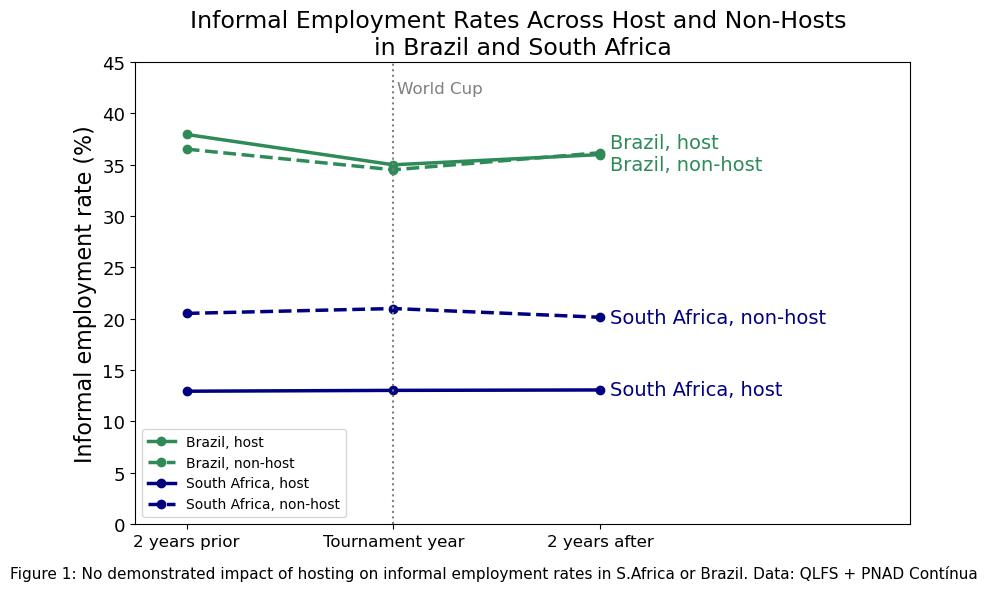

In [35]:
import matplotlib.pyplot as plt

# a ton of this plotting language is taken heavily from the classwork

# make x-axis is years relative to the tournament so both countries share a scale
relative_years = [-2, 0, 2]

# South Africa: southafrica_informal is indexed by (year, host_group)
southafrica_host = [southafrica_informal[(year, "Metro Host")] for year in [2008, 2010, 2012]]
southafrica_nonhost = [southafrica_informal[(year, "Non-Host")] for year in [2008, 2010, 2012]]

# Brazil: brazil_contrib has one row per metro, so average within host group
brazil_means = brazil_socialsecurity.groupby("host_group")[
    ["informal_2012", "informal_2014", "informal_2016"]].mean()
brazil_host = brazil_means.loc["Metro Host"].tolist()
brazil_nonhost = brazil_means.loc["Non-Host"].tolist()

print(southafrica_host, southafrica_nonhost)
print(brazil_host, brazil_nonhost)

plt.figure(figsize=(10, 6))

# color = country, line style = host status
plt.plot(relative_years, brazil_host, color="seagreen", linestyle="-",
         marker="o", linewidth=2.5, label="Brazil, host")
plt.plot(relative_years, brazil_nonhost, color="seagreen", linestyle="--",
         marker="o", linewidth=2.5, label="Brazil, non-host")
plt.plot(relative_years, southafrica_host, color="navy", linestyle="-",
         marker="o", linewidth=2.5, label="South Africa, host")
plt.plot(relative_years, southafrica_nonhost, color="navy", linestyle="--",
         marker="o", linewidth=2.5, label="South Africa, non-host")

# label the line ends
plt.text(2.1, brazil_nonhost[2] - 1.2, "Brazil, non-host", color="seagreen", fontsize=14, va="center")
plt.text(2.1, brazil_host[2] + 1.2, "Brazil, host", color="seagreen", fontsize=14, va="center")
plt.text(2.1, southafrica_nonhost[2], "South Africa, non-host", color="navy", fontsize=14, va="center")
plt.text(2.1, southafrica_host[2], "South Africa, host", color="navy", fontsize=14, va="center")

# add a legend
plt.legend()

# mark the tournament
plt.axvline(0, color="gray", linestyle=":", linewidth=1.5)
plt.text(0.45, 42, "World Cup", ha="center", fontsize=12, color="gray")

plt.xticks(relative_years, ["2 years prior", "Tournament year", "2 years after"], fontsize=12)
plt.yticks(fontsize=13)
plt.ylabel("Informal employment rate (%)", fontsize=16)
plt.ylim(0, 45)
plt.xlim(-2.5, 5)

plt.title("Informal Employment Rates Across Host and Non-Hosts \nin Brazil and South Africa",
          fontsize=17)

plt.figtext(0, 0.02,
            "Figure 1: No demonstrated impact of hosting on informal employment rates in S.Africa or Brazil. Data: QLFS + PNAD Contínua",
            fontsize=11)

plt.savefig(output + "fig1_informality_aggregate.png")
plt.show()

### Figure 2: Informal employment rates disaggregated by cities (host + non-host) across four years. Brazil + South Africa

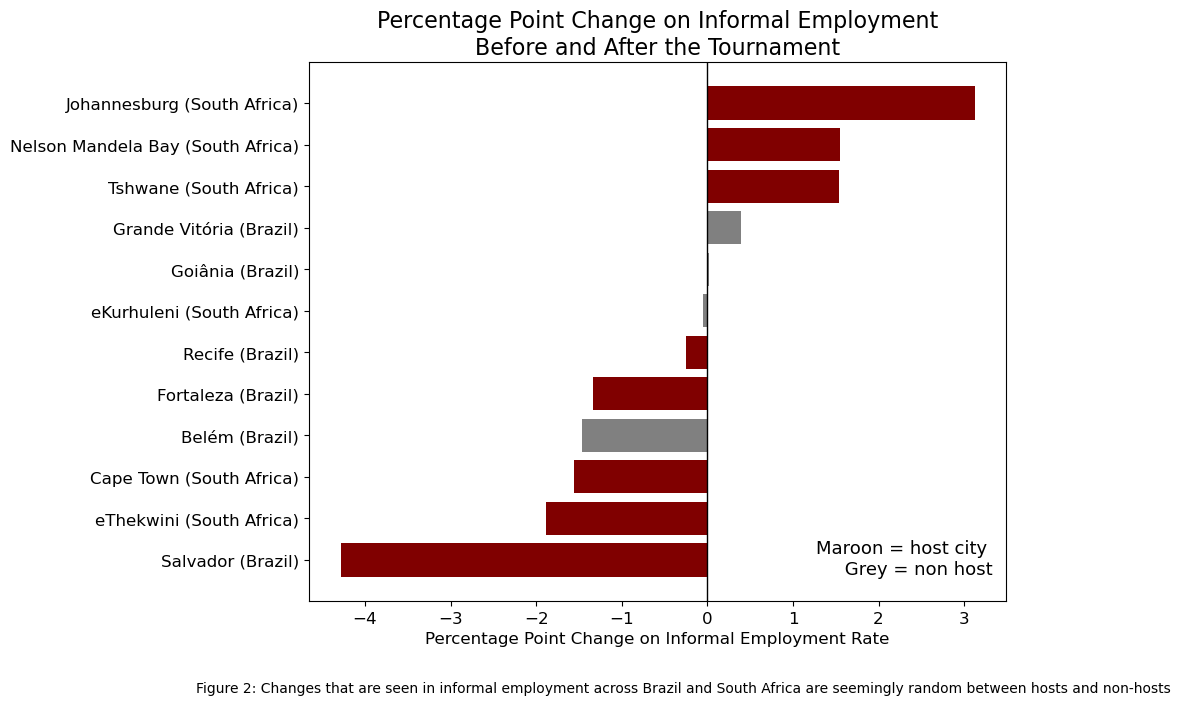

In [40]:
# alter names to be ready to be shown on a graph
metro_display = {
    "cape town": "Cape Town",
    "johannesburg": "Johannesburg",
    "tshwane": "Tshwane",
    "ethekwini": "eThekwini",
    "nelson mandela metro": "Nelson Mandela Bay",
    "ekurhuleni": "eKurhuleni",
    "Salvador (BA)": "Salvador",
    "Recife (PE)": "Recife",
    "Fortaleza (CE)": "Fortaleza",
    "Goiânia (GO)": "Goiânia",
    "Belém (PA)": "Belém",
    "Grande Vitória (ES)": "Grande Vitória",}

# replace names
metro_change["display"] = metro_change["metro"].replace(metro_display)
labels = metro_change["display"] + " (" + metro_change["country"] + ")"

plt.figure(figsize=(9, 7))
colors = metro_change["host_group"].apply(
    lambda x: "maroon" if x == "Metro Host" else "gray")

plt.barh(labels, metro_change["change"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Percentage Point Change on Informal Employment Rate", fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title("Percentage Point Change on Informal Employment\nBefore and After the Tournament", fontsize=16)

plt.text(0.98, 0.05, "Maroon = host city \n Grey = non host", transform=plt.gca().transAxes,
         ha="right", fontsize=13, color="black")
plt.figtext(0, -0.02,
            "Figure 2: Changes that are seen in informal employment across Brazil and South Africa are seemingly random between hosts and non-hosts",
            fontsize=10)
plt.savefig(output + "fig2_informality_disaggregate.png")
plt.show()

### Figure 3: Johannesburg informal employment rates by gender

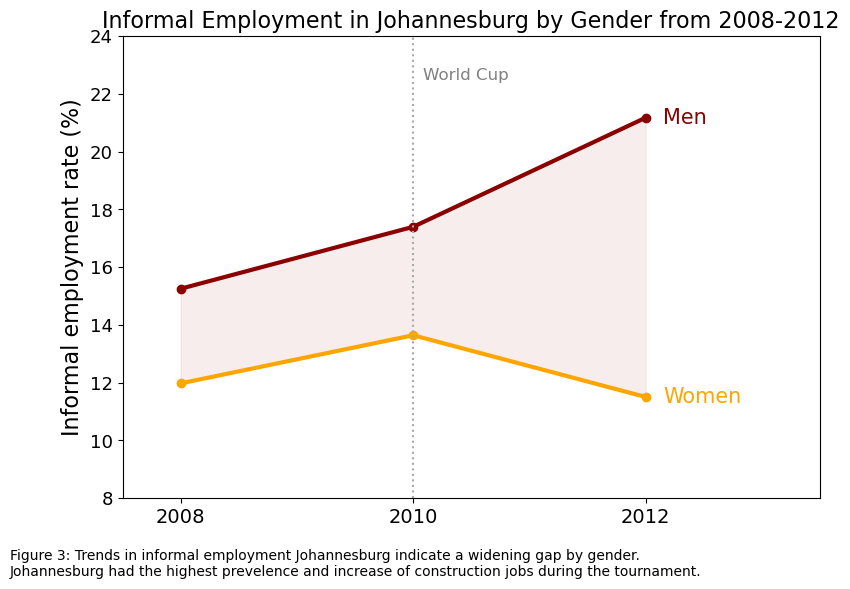

In [42]:
plt.figure(figsize=(9, 6))

plt.plot(relative_years, male, color="darkred", marker="o", linewidth=3)
plt.plot(relative_years, female, color="orange", marker="o", linewidth=3)

plt.text(2.15, male[2], "Men", color="darkred", fontsize=15, va="center")
plt.text(2.15, female[2], "Women", color="orange", fontsize=15, va="center")

# shade the gap between the two lines
plt.fill_between(relative_years, male, female, color="firebrick", alpha=0.08)

plt.axvline(0, color="darkgray", linestyle=":", linewidth=1.5)
plt.text(0.45, 22.5, "World Cup", ha="center", fontsize=12, color="gray")

plt.xticks(relative_years, ["2008", "2010", "2012"], fontsize=14)
plt.yticks(fontsize=13)
plt.ylabel("Informal employment rate (%)", fontsize=16)
plt.xlim(-2.5, 3.5)
plt.ylim(8, 24)

plt.title("Informal Employment in Johannesburg by Gender from 2008-2012",
          fontsize=16)

plt.figtext(0, -0.02,
            "Figure 3: Trends in informal employment Johannesburg indicate a widening gap by gender.\nJohannesburg had the highest prevelence and increase of construction jobs during the tournament.",
            fontsize=10)

plt.savefig(output + "fig3_johannesburg_gender.png")
plt.show()

### Figure 4: Johannesburg male informality rates by sector

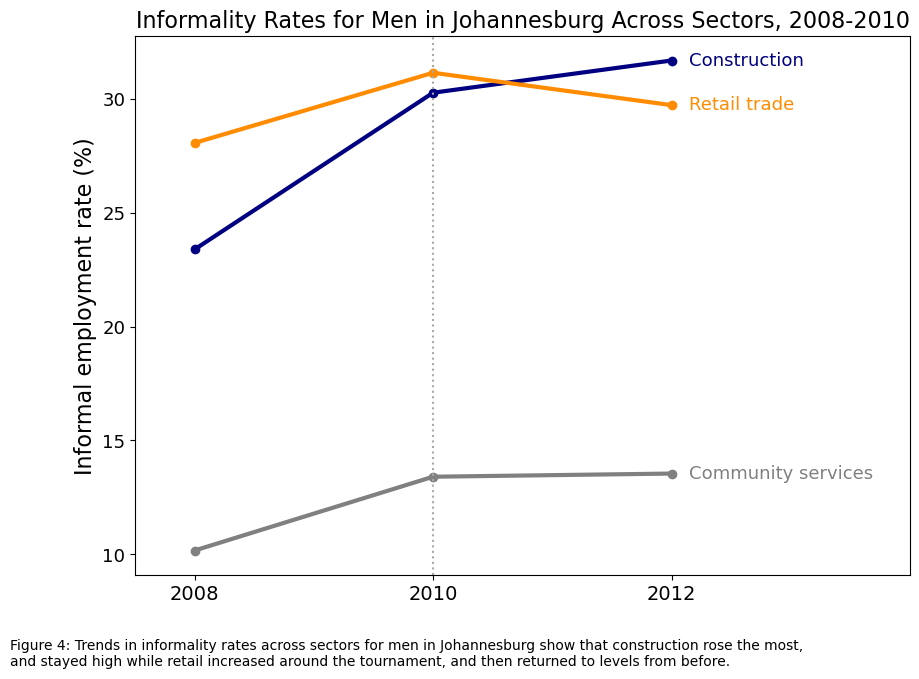

In [47]:
plt.figure(figsize=(10, 7))

sector_colors = {
    "Construction": "navy",
    "Wholesale and retail trade": "darkorange",
    "Community, social and personal services": "gray"}
sector_labels = {
    "Construction": "Construction",
    "Wholesale and retail trade": "Retail trade",
    "Community, social and personal services": "Community services"}

# sector_rates was built in the rates section above
for sector, color in sector_colors.items():
    values = sector_rates[sector]
    plt.plot(relative_years, values, color=color, marker="o", linewidth=3)
    plt.text(2.15, values[2], sector_labels[sector], color=color, fontsize=13, va="center")

# add line for tournament date (same as i have been doing before)
plt.axvline(0, color="darkgray", linestyle=":", linewidth=1.5)

plt.xticks(relative_years, ["2008", "2010", "2012"], fontsize=14)
plt.yticks(fontsize=13)
plt.ylabel("Informal employment rate (%)", fontsize=16)
plt.xlim(-2.5, 4)
plt.title("Informality Rates for Men in Johannesburg Across Sectors, 2008-2010", fontsize=16)

plt.figtext(0, -0.02,
            "Figure 4: Trends in informality rates across sectors for men in Johannesburg show that construction rose the most, \nand stayed high while retail increased around the tournament, and then returned to levels from before.",
            fontsize=10)

plt.savefig(output + "fig4_johannesburg_sectors.png")
plt.show()